# CRNN OCR: experiments

Запускайте ячейки сверху вниз.

Вся логика в `src/notebook_runner.py` и соседних модулях `src/`. Здесь только параметры и вызовы.

In [1]:
# Imports and paths
import sys
import random
import logging
from pathlib import Path

import yaml
import numpy as np
import torch

PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger('experiments')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'config.yaml'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'checkpoints'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('CONFIG_PATH =', CONFIG_PATH)


PROJECT_ROOT = /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition
CONFIG_PATH = /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition/configs/config.yaml


In [2]:
# Device
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print('Using CUDA:', torch.cuda.get_device_name(0))
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print('Using MPS')
else:
    DEVICE = torch.device('cpu')
    print('Using CPU')


Using MPS


In [3]:
# Load config + paths
with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# TRAINING=True -> train; TRAINING=False -> only load weights + eval
TRAINING = False

# config['epochs'] = 1  # smoke test

images_dir = Path(config['images_dir'])
labels_path = Path(config['labels_path'])
if not images_dir.is_absolute():
    images_dir = PROJECT_ROOT / images_dir
if not labels_path.is_absolute():
    labels_path = PROJECT_ROOT / labels_path

assert images_dir.is_dir(), f'Images directory not found: {images_dir}'
assert labels_path.is_file(), f'Labels file not found: {labels_path}'

print('images_dir =', images_dir)
print('labels_path =', labels_path)


images_dir = /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition/data/raw/imgs1_w/imgs1
labels_path = /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition/data/raw/imgs1_w/imgs1_text_recog.csv


In [4]:
from src.notebook_runner import build_dataloaders

dataset, train_dataset, val_dataset, train_loader, val_loader = build_dataloaders(
    str(images_dir),
    str(labels_path),
    config,
    split_seed=SEED,
)

print('Dataset size:', len(dataset))
print('Train size:', len(train_dataset))
print('Val size:', len(val_dataset))


INFO:root:Dataset loaded with 245995 samples (NaN filtered)


Dataset size: 245995
Train size: 196796
Val size: 49199


In [5]:
from src.notebook_runner import build_model_bundle, print_ctc_capacity_warning

model, optimizer, criterion = build_model_bundle(config, DEVICE)
print_ctc_capacity_warning(model, dataset, config, DEVICE)


Model time steps (T): 16
Samples with label length > T: 384/245995


In [6]:
from src.notebook_runner import train_with_checkpoints

CHECKPOINT_PATH = OUTPUT_DIR / 'checkpoint.pth'
BEST_PATH = OUTPUT_DIR / 'best_model.pth'

train_with_checkpoints(
    model,
    optimizer,
    criterion,
    train_loader,
    val_loader,
    config,
    DEVICE,
    CHECKPOINT_PATH,
    BEST_PATH,
    TRAINING,
)


TRAINING=False -> training is skipped. Will load saved weights in next cell.


In [7]:
from src.notebook_runner import load_weights_for_inference

load_weights_for_inference(model, BEST_PATH, CHECKPOINT_PATH, DEVICE)


Checkpoint loaded: /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition/outputs/checkpoints/best_model.pth


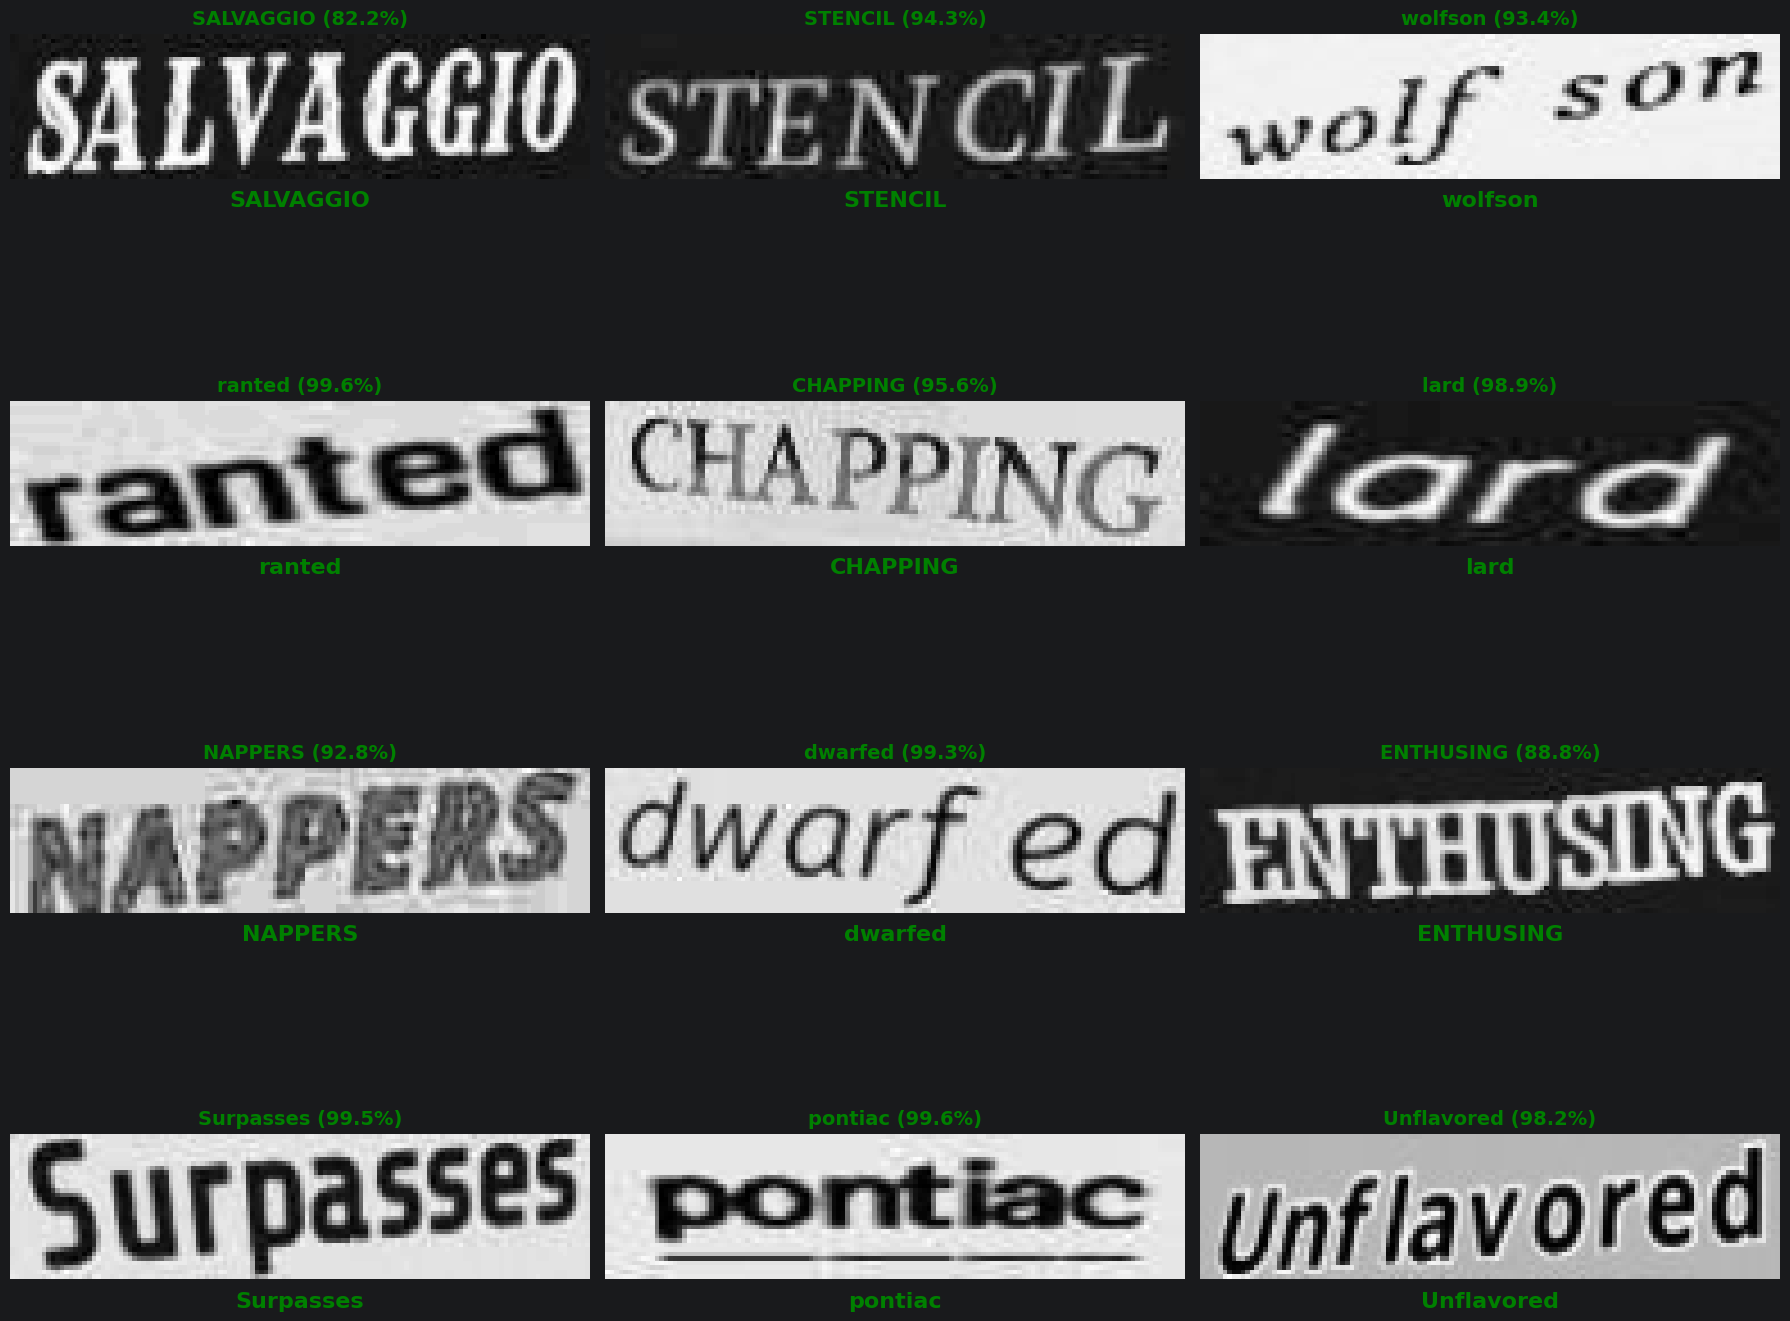

Shown samples: 12
Correct words: 12/12
Accuracy: 1.000
CER: 0.000
WER: 0.000
Average confidence: 95.2%


In [8]:
from src.notebook_runner import visualize_val_predictions

USE_FIXED_SAMPLES = True
FIXED_SAMPLES_SEED = 42

visualize_val_predictions(
    model,
    val_dataset,
    config,
    DEVICE,
    sample_count=12,
    fixed=USE_FIXED_SAMPLES,
    seed=FIXED_SAMPLES_SEED,
)


## Быстрый smoke-test
- В ячейке конфига: `config['epochs'] = 1`
- При необходимости уменьшите `config['batch_size']`


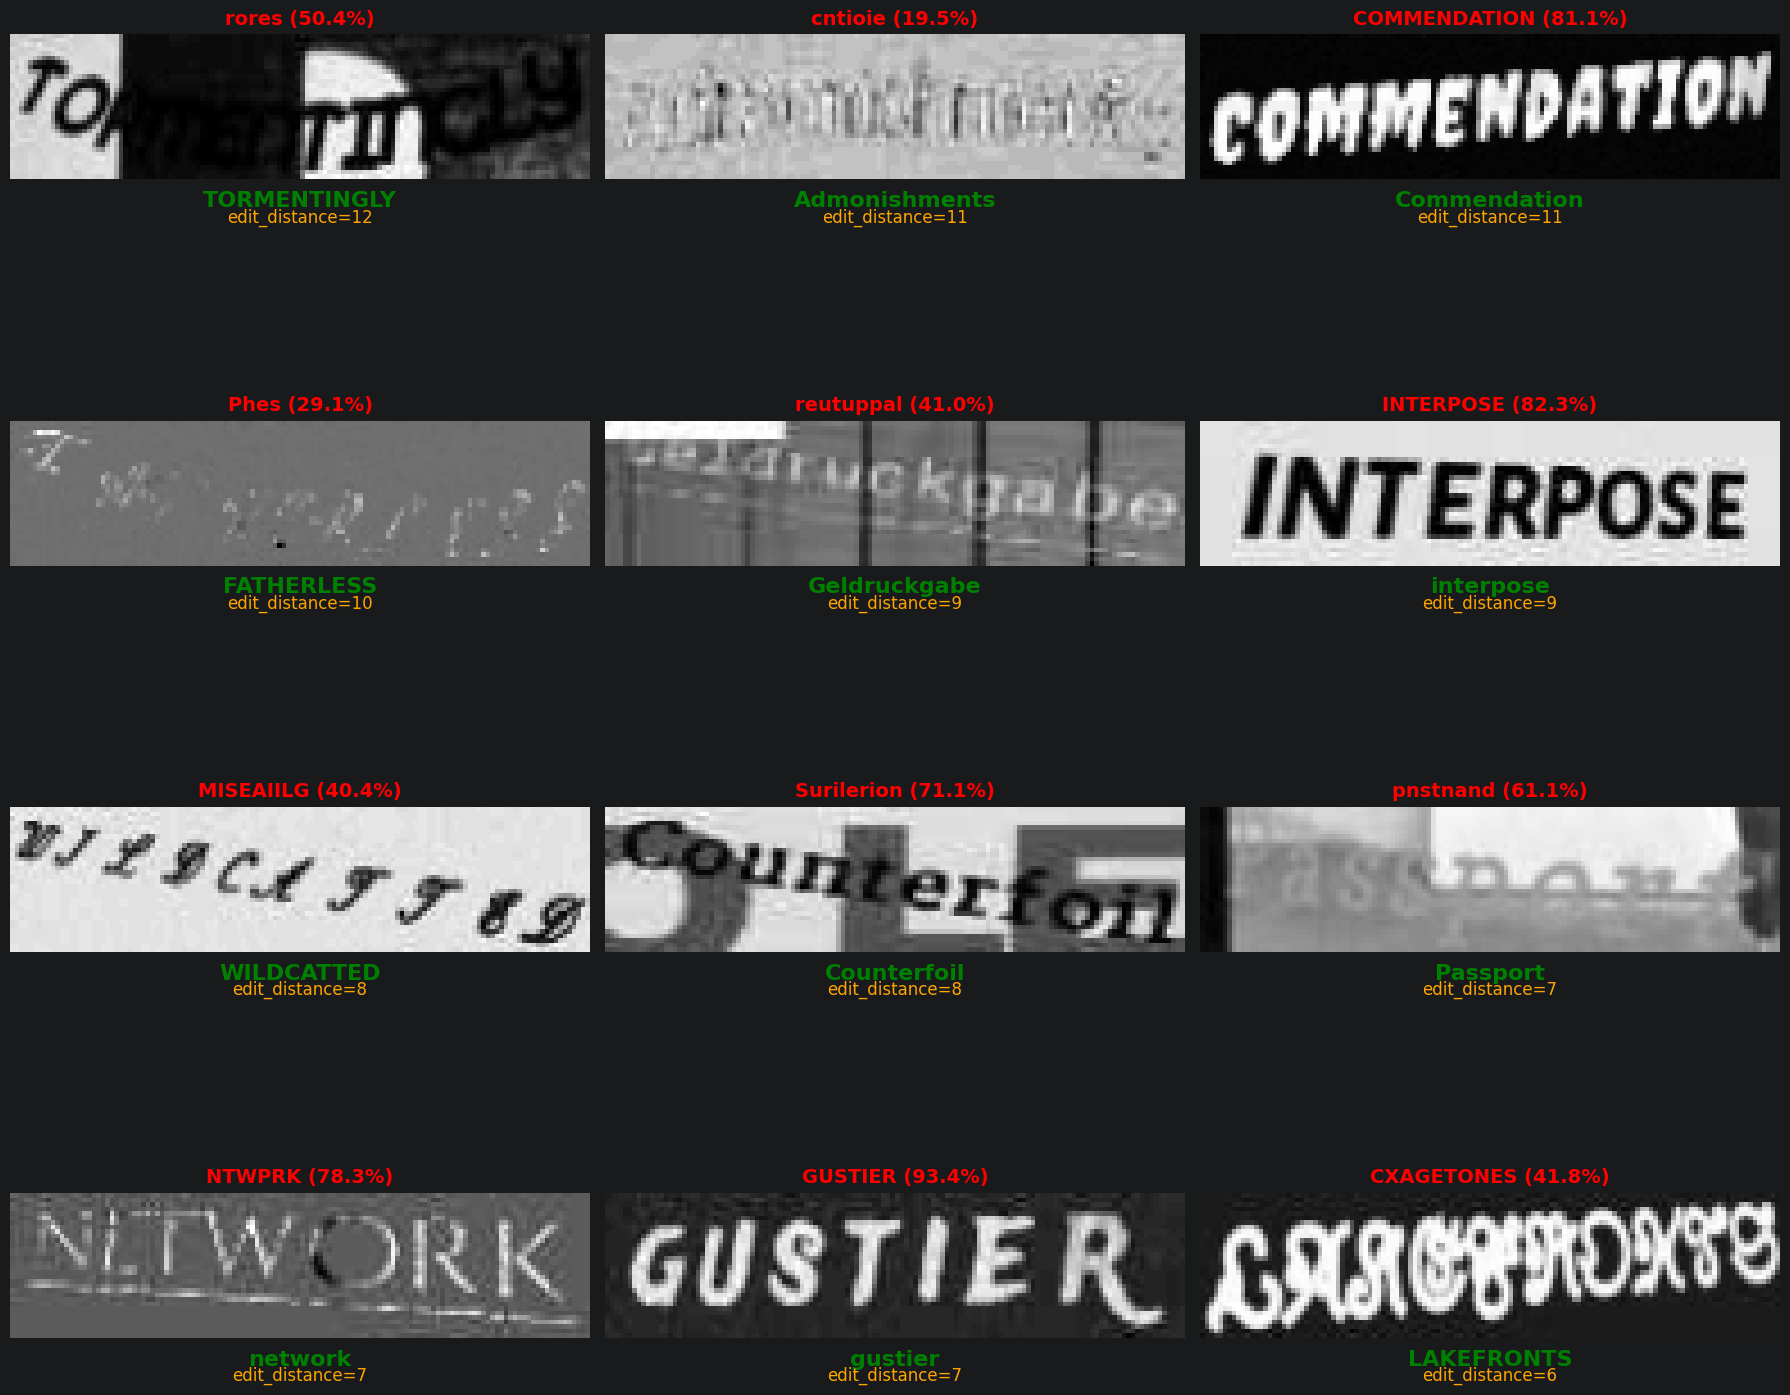

Analyzed samples: 200
Mistakes in analyzed set: 85/200
Showing hardest cases by edit distance.


In [9]:
from src.notebook_runner import show_hard_val_examples

ERROR_ANALYSIS_SAMPLES = 200
ERROR_ANALYSIS_TOP_K = 12

show_hard_val_examples(
    model,
    val_dataset,
    config,
    DEVICE,
    sample_count=ERROR_ANALYSIS_SAMPLES,
    top_k=ERROR_ANALYSIS_TOP_K,
    fixed=USE_FIXED_SAMPLES,
    seed=FIXED_SAMPLES_SEED,
)


In [10]:
from src.notebook_runner import run_leaderboard_log

LEADERBOARD_EVAL_SAMPLES = 500

run_leaderboard_log(
    model,
    val_dataset,
    config,
    DEVICE,
    PROJECT_ROOT,
    BEST_PATH,
    CHECKPOINT_PATH,
    TRAINING,
    sample_count=LEADERBOARD_EVAL_SAMPLES,
    fixed=USE_FIXED_SAMPLES,
    seed=FIXED_SAMPLES_SEED,
    note='leaderboard',
)


Current run metrics on leaderboard subset:
Accuracy: 57.80%
CER: 16.33%
WER: 42.20%
Average confidence: 86.24%
Logged to: /Users/user/PycharmProjects/Learning/MLC/projects/crnn-text-recognition/outputs/experiment_log.csv
Saved run: acc=57.80% cer=16.33% wer=42.20% conf=86.24%
Total logged runs: 2


,timestamp,mode,sample_count,accuracy_%,cer_%,wer_%,avg_conf_%,batch_size,lr,weights,note
0,2026-04-21 21:30:26,inference_only,500,57.8,16.33,42.2,86.24,32,0.001,best_model.pth,leaderboard
1,2026-04-21 19:59:31,inference_only,500,57.2,15.04,42.8,86.95,32,0.001,best_model.pth,step5 leaderboard
